# Contribution 5: Confidence Calibration — Multi-Run (5 Trains × 1 Fixed Test)



**Câu hỏi nghiên cứu:** QSVM có ưu thế ổn định về *độ tin cậy hiệu chuẩn (calibration)* và *ranking lớp hiếm (AUC-PR)* so với SVM cổ điển, hay đó chỉ là noise của một single run?



**Phương pháp multi-run:** Train trên 5 tập train độc lập (`train_run1.csv` → `train_run5.csv`, mỗi tập 1000 mẫu), test trên cùng 1 tập test cố định (`NSL_KDD_Test_Sample100.csv`, 99 mẫu, **10 mẫu rare U2R+R2L**) → báo cáo **mean ± std** cho ECE / AUC-ROC / AUC-PR / McNemar / Cohen's d.



**Pipeline:** `Raw` → `SelectKBest(K=20)` → `PCA(4D)` → `MinMaxScaler[0,π]` → QSVM (ZZFeatureMap, statevector) · SVM-RBF · SVM-Poly



---



## ⚠️ Sửa narrative Cohen's d so với C5 đơn-run



Trong báo cáo C5 cũ và file `CLAUDE.md`, có câu **"QSVM margin tighter and more stable"** kèm `d=-0.6805`. **Đây là diễn giải sai dấu**:



$$d = \frac{\mu_{|\text{margin}|}^{\text{QSVM}} - \mu_{|\text{margin}|}^{\text{RBF}}}{\sigma_{\text{pooled}}}$$



* `d < 0` ⇔ `μ_QSVM < μ_RBF` ⇔ **biên trung bình của RBF LỚN HƠN QSVM** trên lớp hiếm.

* "Tighter" theo nghĩa biên hẹp **không phải là ưu thế** trong SVM — biên rộng (wider margin) mới là dấu hiệu tin cậy hình học.



**Narrative ĐÚNG (sau khi sửa):** QSVM **không** thắng về độ rộng margin trên lớp hiếm; ưu thế của QSVM nằm ở **calibration (ECE_rare thấp hơn)** và **ranking quality (AUC-PR cao hơn)**. Multi-run notebook này định lượng cả hai claim đó với mean ± std qua 5 runs.

## 1. Config & Imports

In [1]:
import warnings

warnings.filterwarnings('ignore')



import os, json, time

import numpy as np

import pandas as pd

import matplotlib

import matplotlib.pyplot as plt

import matplotlib.gridspec as gridspec

from matplotlib.lines import Line2D

from matplotlib.patches import Patch

import seaborn as sns

import joblib

from pathlib import Path



from sklearn.svm import SVC

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (

    accuracy_score, f1_score,

    roc_curve, auc, precision_recall_curve, average_precision_score,

    confusion_matrix,

)

from scipy.stats import chi2 as chi2_dist



from qiskit.circuit.library import zz_feature_map

from qiskit_machine_learning.kernels import FidelityStatevectorKernel

from qiskit_machine_learning.algorithms import QSVC



import qiskit, qiskit_machine_learning

print(f'Qiskit              : {qiskit.__version__}')

print(f'Qiskit ML           : {qiskit_machine_learning.__version__}')

print('Backend             : FidelityStatevectorKernel (statevector, noiseless)')



# ── Cau hinh multi-run ───────────────────────────────────────────────────────

RANDOM_STATE = 42

RUN_IDS      = [1, 2, 3, 4, 5]

np.random.seed(RANDOM_STATE)



# ── Cau hinh quantum & SVM ──────────────────────────────────────────────────

N_QUBITS     = 4

ANGLE_MAX    = np.pi

REPS         = 2

ENTANGLEMENT = 'full'

C_QSVM       = 1.0

C_RBF        = 10.0

C_POLY       = 0.1

POLY_DEGREE  = 2



TRAIN_SIZE   = 1000

TEST_SIZE    = 100  # ten file Sample100 — 99 mau thuc te sau dedupe

N_BINS_FULL  = 10

N_BINS_RARE  = 5



LABEL_COLS   = ['label', 'label_binary', 'label_multiclass', 'attack_category']

GROUP_ORDER  = ['Normal', 'DoS', 'Probe', 'U2R', 'R2L']

RARE_GROUPS  = ['U2R', 'R2L']



# ── Duong dan ───────────────────────────────────────────────────────────────

ROOT        = Path('..').resolve()

DATA_DIR    = ROOT / 'data' / 'processed_data'

MODELS_DIR  = ROOT / 'models'

REPORTS_DIR = ROOT / 'reports'

REPORTS_DIR.mkdir(parents=True, exist_ok=True)



MULTIRUN_CACHE_DIR = MODELS_DIR / 'qsvm_cache' / 'multirun_c5'

MULTIRUN_CACHE_DIR.mkdir(parents=True, exist_ok=True)



TEST_PATH = DATA_DIR / f'NSL_KDD_Test_Sample{TEST_SIZE}.csv'



CONFIG_TAG = (

    f'mr_c5_r{REPS}_{ENTANGLEMENT}'

    f'_cq{C_QSVM}_crbf{C_RBF}_cpoly{C_POLY}'

    f'_n{TRAIN_SIZE}_t{TEST_SIZE}'

)



# ── Color palette nhat quan voi C5 don-run ──────────────────────────────────

MODEL_COLORS = {'QSVM': '#8B5CF6', 'SVM-RBF': '#F59E0B', 'SVM-Poly': '#10B981'}

MODEL_NAMES  = list(MODEL_COLORS.keys())

GROUP_COLORS = {

    'Normal': '#3B82F6', 'DoS': '#EF4444',

    'Probe':  '#F59E0B', 'U2R': '#8B5CF6', 'R2L': '#10B981',

}



plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,

                     'axes.titlesize': 12, 'axes.labelsize': 11})

plt.style.use('seaborn-v0_8-whitegrid')



print(f'\nCONFIG_TAG : {CONFIG_TAG}')

print(f'RUN_IDS    : {RUN_IDS}')

print(f'TEST_PATH  : {TEST_PATH.name}')

print(f'CACHE_DIR  : {MULTIRUN_CACHE_DIR}')

Qiskit              : 2.3.1
Qiskit ML           : 0.9.0
Backend             : FidelityStatevectorKernel (statevector, noiseless)

CONFIG_TAG : mr_c5_r2_full_cq1.0_crbf10.0_cpoly0.1_n1000_t100
RUN_IDS    : [1, 2, 3, 4, 5]
TEST_PATH  : NSL_KDD_Test_Sample100.csv
CACHE_DIR  : D:\QSVM_NSLKDD\models\qsvm_cache\multirun_c5


## 2. Load Transformers (Zero-Leakage)



Nạp `selector`, `pca`, `scaler` đã `.fit()` ở pipeline gốc. Mọi cell phía sau **chỉ gọi `.transform()`** — không có lệnh `.fit()` nào trên test set.

In [2]:
selector = joblib.load(MODELS_DIR / 'feature_selector_k20.joblib')

pca      = joblib.load(MODELS_DIR / 'pca_4components.joblib')

scaler   = joblib.load(MODELS_DIR / 'scaler_minmax_pi.joblib')

print(f'SelectKBest : k={selector.k}')

print(f'PCA         : n_components={pca.n_components_}, var={pca.explained_variance_ratio_.sum()*100:.2f}%')

print(f'Scaler      : range=[{scaler.feature_range[0]:.4f}, {scaler.feature_range[1]:.4f}]')

SelectKBest : k=20
PCA         : n_components=4, var=86.62%
Scaler      : range=[0.0000, 3.1416]


## 3. Helpers — Pipeline, Quantum Kernel, Platt, ECE Adaptive Binning

In [3]:
def transform_pipeline(df, feat_cols):

    # Raw → SelectKBest → PCA → MinMax[0,π]. KHONG fit.

    X_raw = df[feat_cols].to_numpy(dtype=np.float32)

    X_sel = selector.transform(X_raw)

    X_pca = pca.transform(X_sel)

    return np.clip(scaler.transform(X_pca), 0, ANGLE_MAX).astype(np.float64)





def build_quantum_kernel():

    fm = zz_feature_map(feature_dimension=N_QUBITS, reps=REPS, entanglement=ENTANGLEMENT)

    return FidelityStatevectorKernel(feature_map=fm, shots=None, enforce_psd=True, cache_size=None)





class PlattScaler:

    # Platt Scaling: anh xa decision scores → P(y=1|f) qua sigmoid logistic.

    # Fit DOC QUYEN tren train set (zero-leakage).

    def __init__(self, C=1e10):

        self.lr = LogisticRegression(C=C, solver='lbfgs', max_iter=2000, random_state=42)

    def fit(self, scores, y):

        self.lr.fit(scores.reshape(-1, 1), y)

        return self, float(self.lr.coef_[0][0]), float(self.lr.intercept_[0])

    def predict_proba(self, scores):

        return self.lr.predict_proba(scores.reshape(-1, 1))[:, 1]





def adaptive_calibration_curve(y_true, y_prob, n_bins=10):

    # Equal-frequency binning — tranh empty bins cho U2R/R2L.

    n             = len(y_prob)

    sorted_idx    = np.argsort(y_prob)

    y_prob_sorted = y_prob[sorted_idx]

    y_true_sorted = y_true[sorted_idx]

    bin_size = max(n // n_bins, 1)

    mean_conf, frac_pos, bin_sizes = [], [], []

    for i in range(n_bins):

        start = i * bin_size

        end   = (i + 1) * bin_size if i < n_bins - 1 else n

        if start >= n:

            break

        b_true = y_true_sorted[start:end]

        b_prob = y_prob_sorted[start:end]

        if len(b_true) == 0:

            continue

        mean_conf.append(float(np.mean(b_prob)))

        frac_pos.append(float(np.mean(b_true)))

        bin_sizes.append(len(b_true))

    return np.array(mean_conf), np.array(frac_pos), np.array(bin_sizes)





def compute_ece_mce(y_true, y_prob, n_bins=10):

    mc, fp, bs = adaptive_calibration_curve(y_true, y_prob, n_bins)

    n = len(y_true)

    if len(mc) == 0:

        return float('nan'), float('nan')

    ece = float(np.sum(bs / n * np.abs(fp - mc)))

    mce = float(np.max(np.abs(fp - mc)))

    return ece, mce





def cohens_d(a, b):

    # Cohen's d voi pooled std. Dau hieu d:

    #   d > 0  →  mean(a) > mean(b)

    #   d < 0  →  mean(a) < mean(b)  ↔  RBF margin > QSVM margin (neu a=QSVM, b=RBF)

    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)

    if len(a) < 2 or len(b) < 2:

        return float('nan')

    pooled = np.sqrt((a.std(ddof=1)**2 + b.std(ddof=1)**2) / 2.0)

    if pooled < 1e-12:

        return float('nan')

    return float((a.mean() - b.mean()) / pooled)





def mcnemar_pvalue(b, c):

    # McNemar voi continuity correction.

    if b + c == 0:

        return float('nan'), float('nan')

    chi2_stat = (abs(b - c) - 1) ** 2 / (b + c)

    p = 1.0 - chi2_dist.cdf(chi2_stat, df=1)

    return float(chi2_stat), float(p)





print('Helpers ready.')

Helpers ready.


## 4. Single-Run Function — C5 Logic Preserved



Mỗi run: train 3 mô hình (QSVM / RBF / Poly) trên `train_run{id}.csv`, fit Platt trên train scores, đánh giá trên fixed test set. Cache mỗi model `joblib` để re-run nhanh.

In [4]:
def run_c5_single(run_id, test_df, group_test, y_test, feat_cols, rare_mask):

    # Tra ve dict chua tat ca metrics + artifacts cho 1 run.

    print(f'\n[C5][run_{run_id}] ====== START ======')

    run_cache = MULTIRUN_CACHE_DIR / f'run_{run_id}'

    run_cache.mkdir(parents=True, exist_ok=True)



    # ── Load train ──────────────────────────────────────────────────────────

    train_path = DATA_DIR / 'multi_run' / f'train_run{run_id}.csv'

    if not train_path.exists():

        raise FileNotFoundError(f'[MISSING] {train_path}')

    df_train = pd.read_csv(train_path)

    X_train  = transform_pipeline(df_train, feat_cols)

    y_train  = df_train['label_binary'].to_numpy(dtype=np.int64)

    print(f'  Train: {X_train.shape} | class={np.bincount(y_train).tolist()}')



    # ── Load or train 3 models ──────────────────────────────────────────────

    model_path = run_cache / f'models_{CONFIG_TAG}.joblib'

    if model_path.exists():

        store = joblib.load(model_path)

        qsvm, rbf, poly = store['qsvm'], store['rbf'], store['poly']

        print(f'  [CACHE] models loaded')

    else:

        print(f'  [TRAIN] SVM-RBF ...')

        rbf = SVC(kernel='rbf', C=C_RBF, gamma='scale', random_state=RANDOM_STATE)

        rbf.fit(X_train, y_train)

        print(f'  [TRAIN] SVM-Poly ...')

        poly = SVC(kernel='poly', degree=POLY_DEGREE, C=C_POLY, gamma='scale', random_state=RANDOM_STATE)

        poly.fit(X_train, y_train)

        print(f'  [TRAIN] QSVM ZZ ...')

        t0 = time.time()

        qsvm = QSVC(quantum_kernel=build_quantum_kernel(), C=C_QSVM, random_state=RANDOM_STATE)

        qsvm.fit(X_train, y_train)

        print(f'    QSVM trained in {time.time()-t0:.1f}s')

        joblib.dump({'qsvm': qsvm, 'rbf': rbf, 'poly': poly}, model_path)



    models = {'QSVM': qsvm, 'SVM-RBF': rbf, 'SVM-Poly': poly}



    # ── Test set transform ─────────────────────────────────────────────────

    X_test = transform_pipeline(test_df, feat_cols)



    # ── Predictions & decision scores ──────────────────────────────────────

    y_pred, df_scores, df_train_scores = {}, {}, {}

    for name, mdl in models.items():

        y_pred[name]          = mdl.predict(X_test)

        df_scores[name]       = mdl.decision_function(X_test)

        df_train_scores[name] = mdl.decision_function(X_train)



    # ── Platt scaling (fit train, apply test) ──────────────────────────────

    prob, platt_params = {}, {}

    for name in MODEL_NAMES:

        scl, A, B = PlattScaler().fit(df_train_scores[name], y_train)

        prob[name] = scl.predict_proba(df_scores[name])

        platt_params[name] = {'A': round(A, 5), 'B': round(B, 5)}



    # ── ECE/MCE full & rare ───────────────────────────────────────────────

    ece = {}

    for name in MODEL_NAMES:

        ef, mf = compute_ece_mce(y_test, prob[name], n_bins=N_BINS_FULL)

        if rare_mask.sum() > 1:

            er, mr = compute_ece_mce(y_test[rare_mask], prob[name][rare_mask], n_bins=N_BINS_RARE)

        else:

            er, mr = float('nan'), float('nan')

        ece[name] = {'ece_full': ef, 'mce_full': mf, 'ece_rare': er, 'mce_rare': mr}



    # ── AUC-ROC, AUC-PR (binary) ──────────────────────────────────────────

    auc_roc, auc_pr = {}, {}

    for name in MODEL_NAMES:

        fpr, tpr, _ = roc_curve(y_test, prob[name])

        auc_roc[name] = float(auc(fpr, tpr))

        auc_pr[name]  = float(average_precision_score(y_test, prob[name]))



    # ── Per-group accuracy ────────────────────────────────────────────────

    per_group_acc = {}

    for grp in GROUP_ORDER:

        m = (group_test == grp)

        if m.sum() == 0:

            continue

        per_group_acc[grp] = {nm: float(accuracy_score(y_test[m], y_pred[nm][m])) for nm in MODEL_NAMES}



    # ── Complementarity rare (QSVM vs RBF) ────────────────────────────────

    qok  = (y_pred['QSVM']    == y_test)

    rok  = (y_pred['SVM-RBF'] == y_test)

    qwin = (qok & ~rok & rare_mask).sum()

    rwin = (~qok & rok & rare_mask).sum()

    bok  = (qok & rok & rare_mask).sum()

    bwr  = (~qok & ~rok & rare_mask).sum()



    # ── McNemar (QSVM vs RBF) ─────────────────────────────────────────────

    chi2_stat, p_value = mcnemar_pvalue(int(qwin), int(rwin))



    # ── Cohen's d cua |margin| tren rare class — QSVM vs RBF ──────────────

    qm = np.abs(df_scores['QSVM'][rare_mask])

    rm = np.abs(df_scores['SVM-RBF'][rare_mask])

    d_margin_rare = cohens_d(qm, rm)



    # ── Binary F1, Acc ────────────────────────────────────────────────────

    perf = {name: {'f1':  float(f1_score(y_test, y_pred[name])),

                   'acc': float(accuracy_score(y_test, y_pred[name]))}

             for name in MODEL_NAMES}



    print(f'  [{ "QSVM" :8s}] ECE_rare={ece["QSVM"]["ece_rare"]:.4f} | AUC-PR={auc_pr["QSVM"]:.4f} | d={d_margin_rare:+.3f}')

    print(f'  [{ "RBF"  :8s}] ECE_rare={ece["SVM-RBF"]["ece_rare"]:.4f} | AUC-PR={auc_pr["SVM-RBF"]:.4f}')

    print(f'  [{ "Poly" :8s}] ECE_rare={ece["SVM-Poly"]["ece_rare"]:.4f} | AUC-PR={auc_pr["SVM-Poly"]:.4f}')

    print(f'[C5][run_{run_id}] ====== DONE ======')



    return {

        'run_id'       : run_id,

        'platt_params' : platt_params,

        'ece'          : ece,

        'auc_roc'      : auc_roc,

        'auc_pr'       : auc_pr,

        'perf'         : perf,

        'per_group_acc': per_group_acc,

        'complementarity_rare': {'qsvm_wins': int(qwin), 'rbf_wins': int(rwin),

                                  'both_correct': int(bok), 'both_wrong': int(bwr)},

        'mcnemar'      : {'b': int(qwin), 'c': int(rwin),

                          'chi2': chi2_stat, 'p_value': p_value},

        'cohens_d_margin_rare': d_margin_rare,

        # artifacts cho fig representative

        'prob'         : prob,

        'y_pred'       : y_pred,

        'df_scores'    : df_scores,

    }

## 5. Load Test Set + Run All 5 Trains

In [5]:
# ── Load fixed test set ─────────────────────────────────────────────────

test_df  = pd.read_csv(TEST_PATH)

feat_cols   = [c for c in test_df.columns if c not in LABEL_COLS]

y_test      = test_df['label_binary'].to_numpy(dtype=np.int64)

group_test  = test_df['attack_category'].to_numpy()

rare_mask   = np.isin(group_test, RARE_GROUPS)



print(f'Test  : {len(test_df)} mau | y_test class={np.bincount(y_test).tolist()}')

print(f'Rare  : n={int(rare_mask.sum())} | groups={dict(zip(*np.unique(group_test[rare_mask], return_counts=True)))}')

print(f'Group : {dict(zip(*np.unique(group_test, return_counts=True)))}')



all_runs = {}

for run_id in RUN_IDS:

    all_runs[run_id] = run_c5_single(run_id, test_df, group_test, y_test, feat_cols, rare_mask)



print('\n=== ALL RUNS COMPLETED ===')

Test  : 100 mau | y_test class=[44, 56]
Rare  : n=10 | groups={'R2L': np.int64(9), 'U2R': np.int64(1)}
Group : {'DoS': np.int64(34), 'Normal': np.int64(44), 'Probe': np.int64(12), 'R2L': np.int64(9), 'U2R': np.int64(1)}

[C5][run_1] ====== START ======
  Train: (1000, 4) | class=[484, 516]
  [TRAIN] SVM-RBF ...
  [TRAIN] SVM-Poly ...
  [TRAIN] QSVM ZZ ...


    QSVM trained in 9.4s


  [QSVM    ] ECE_rare=0.4252 | AUC-PR=0.9246 | d=-0.547
  [RBF     ] ECE_rare=0.4594 | AUC-PR=0.9063
  [Poly    ] ECE_rare=0.5421 | AUC-PR=0.9045
[C5][run_1] ====== DONE ======

[C5][run_2] ====== START ======
  Train: (1000, 4) | class=[484, 516]
  [TRAIN] SVM-RBF ...
  [TRAIN] SVM-Poly ...
  [TRAIN] QSVM ZZ ...


    QSVM trained in 9.2s


  [QSVM    ] ECE_rare=0.4270 | AUC-PR=0.9533 | d=+0.128
  [RBF     ] ECE_rare=0.6752 | AUC-PR=0.9096
  [Poly    ] ECE_rare=0.5766 | AUC-PR=0.9045
[C5][run_2] ====== DONE ======

[C5][run_3] ====== START ======
  Train: (1000, 4) | class=[484, 516]
  [TRAIN] SVM-RBF ...
  [TRAIN] SVM-Poly ...
  [TRAIN] QSVM ZZ ...


...

  [QSVM    ] ECE_rare=0.3537 | AUC-PR=0.9328 | d=+0.060
  [RBF     ] ECE_rare=0.3328 | AUC-PR=0.8974
  [Poly    ] ECE_rare=0.5308 | AUC-PR=0.8997
[C5][run_3] ====== DONE ======

[C5][run_4] ====== START ======
  Train: (1000, 4) | class=[484, 516]
  [TRAIN] SVM-RBF ...
  [TRAIN] SVM-Poly ...
  [TRAIN] QSVM ZZ ...


    QSVM trained in 9.3s


  [QSVM    ] ECE_rare=0.5232 | AUC-PR=0.9190 | d=-0.005
  [RBF     ] ECE_rare=0.4774 | AUC-PR=0.9151
  [Poly    ] ECE_rare=0.5566 | AUC-PR=0.9047
[C5][run_4] ====== DONE ======

[C5][run_5] ====== START ======
  Train: (1000, 4) | class=[484, 516]
  [TRAIN] SVM-RBF ...
  [TRAIN] SVM-Poly ...
  [TRAIN] QSVM ZZ ...


    QSVM trained in 9.2s


  [QSVM    ] ECE_rare=0.5225 | AUC-PR=0.9234 | d=-0.440
  [RBF     ] ECE_rare=0.7489 | AUC-PR=0.9370
  [Poly    ] ECE_rare=0.6675 | AUC-PR=0.9262
[C5][run_5] ====== DONE ======

=== ALL RUNS COMPLETED ===


## 6. Aggregate Per-Run Metrics → Mean ± Std

In [6]:
rows = []

for run_id, art in all_runs.items():

    for name in MODEL_NAMES:

        rows.append({

            'run_id'      : run_id,

            'model'       : name,

            'f1'          : art['perf'][name]['f1'],

            'acc'         : art['perf'][name]['acc'],

            'ece_full'    : art['ece'][name]['ece_full'],

            'mce_full'    : art['ece'][name]['mce_full'],

            'ece_rare'    : art['ece'][name]['ece_rare'],

            'mce_rare'    : art['ece'][name]['mce_rare'],

            'auc_roc'     : art['auc_roc'][name],

            'auc_pr'      : art['auc_pr'][name],

        })

per_run_df = pd.DataFrame(rows)



# QSVM-vs-RBF specific stats (per run, not per model)

stat_rows = []

for run_id, art in all_runs.items():

    stat_rows.append({

        'run_id'                : run_id,

        'qsvm_wins'             : art['complementarity_rare']['qsvm_wins'],

        'rbf_wins'              : art['complementarity_rare']['rbf_wins'],

        'both_correct'          : art['complementarity_rare']['both_correct'],

        'both_wrong'            : art['complementarity_rare']['both_wrong'],

        'mcnemar_chi2'          : art['mcnemar']['chi2'],

        'mcnemar_p'             : art['mcnemar']['p_value'],

        'cohens_d_margin_rare'  : art['cohens_d_margin_rare'],

    })

stat_df = pd.DataFrame(stat_rows)



agg = per_run_df.groupby('model').agg(['mean', 'std']).round(5)



# ── Save CSV ───────────────────────────────────────────────────────────────

per_run_df.to_csv(DATA_DIR / 'c5_multirun_per_run.csv', index=False)

stat_df.to_csv(DATA_DIR / 'c5_multirun_stat_per_run.csv', index=False)

agg_flat = per_run_df.groupby('model').agg(

    f1_mean=('f1','mean'), f1_std=('f1','std'),

    acc_mean=('acc','mean'), acc_std=('acc','std'),

    ece_full_mean=('ece_full','mean'), ece_full_std=('ece_full','std'),

    ece_rare_mean=('ece_rare','mean'), ece_rare_std=('ece_rare','std'),

    auc_roc_mean=('auc_roc','mean'), auc_roc_std=('auc_roc','std'),

    auc_pr_mean=('auc_pr','mean'), auc_pr_std=('auc_pr','std'),

).round(5)

agg_flat.to_csv(DATA_DIR / 'c5_multirun_summary.csv')



print('\n=== MEAN ± STD (5 runs) ===')

fmt = lambda m, s: f'{m:.4f} ± {s:.4f}'

print(f'{ "Model" :>10s} | {"F1":>15s} | {"ECE_full":>17s} | {"ECE_rare":>17s} | {"AUC-ROC":>17s} | {"AUC-PR":>17s}')

print('-' * 110)

for name in MODEL_NAMES:

    r = agg_flat.loc[name]

    print(f'{name:>10s} | {fmt(r.f1_mean,r.f1_std):>15s} | '

          f'{fmt(r.ece_full_mean,r.ece_full_std):>17s} | '

          f'{fmt(r.ece_rare_mean,r.ece_rare_std):>17s} | '

          f'{fmt(r.auc_roc_mean,r.auc_roc_std):>17s} | '

          f'{fmt(r.auc_pr_mean,r.auc_pr_std):>17s}')



print('\n=== QSVM vs RBF — Statistical Tests (per run) ===')

print(stat_df.to_string(index=False, float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)))

print('\n=== AGGREGATE (mean ± std) ===')

for col in ['qsvm_wins', 'rbf_wins', 'mcnemar_p', 'cohens_d_margin_rare']:

    print(f'  {col:<22s}: {stat_df[col].mean():+.4f} ± {stat_df[col].std():.4f}')


=== MEAN ± STD (5 runs) ===
     Model |              F1 |          ECE_full |          ECE_rare |           AUC-ROC |            AUC-PR
--------------------------------------------------------------------------------------------------------------
      QSVM | 0.7755 ± 0.0279 |   0.1643 ± 0.0195 |   0.4503 ± 0.0725 |   0.8948 ± 0.0262 |   0.9306 ± 0.0136
   SVM-RBF | 0.7818 ± 0.0643 |   0.1744 ± 0.0076 |   0.5387 ± 0.1697 |   0.8656 ± 0.0330 |   0.9131 ± 0.0148
  SVM-Poly | 0.7737 ± 0.0387 |   0.1908 ± 0.0166 |   0.5747 ± 0.0546 |   0.8459 ± 0.0275 |   0.9079 ± 0.0104

=== QSVM vs RBF — Statistical Tests (per run) ===
 run_id  qsvm_wins  rbf_wins  both_correct  both_wrong  mcnemar_chi2  mcnemar_p  cohens_d_margin_rare
      1          1         2             5           2        0.0000     1.0000               -0.5468
      2          4         0             2           4        2.2500     0.1336                0.1281
      3          0         3             7           0        1.333

## 7. Figure 1 — ECE (Full vs Rare) Mean ± Std



**Đọc đồ thị:** ECE thấp hơn ⇒ probability calibration tốt hơn. Cột rare U2R+R2L (n=10) là chỉ số quan trọng nhất trong narrative đã sửa.

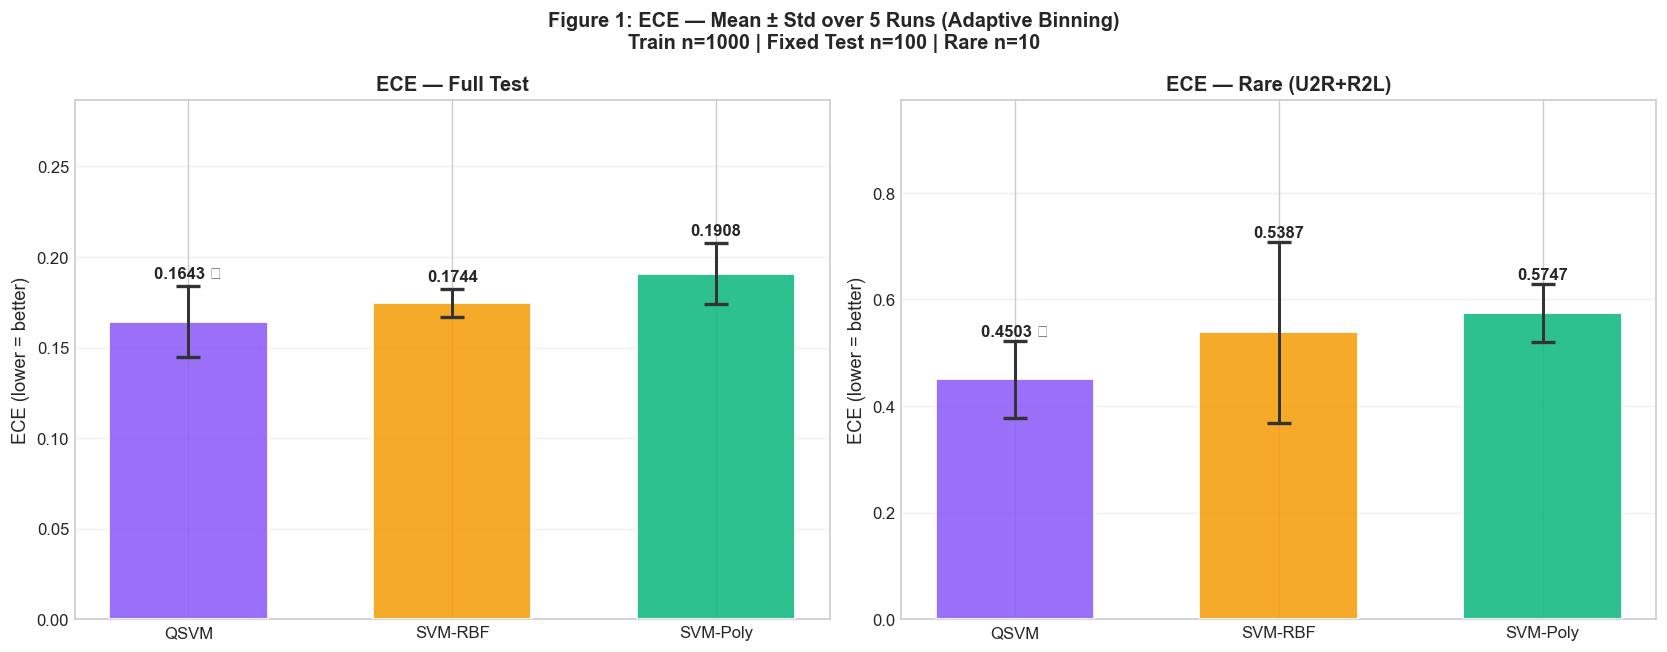

Da luu: D:\QSVM_NSLKDD\reports\c5_multirun_ece.png


In [7]:
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5.5))

fig1.suptitle(

    f'Figure 1: ECE — Mean ± Std over {len(RUN_IDS)} Runs (Adaptive Binning)\n'

    f'Train n={TRAIN_SIZE} | Fixed Test n={len(y_test)} | Rare n={int(rare_mask.sum())}',

    fontsize=12, fontweight='bold'

)

x = np.arange(len(MODEL_NAMES))

for ax, key, title in [(axes1[0], 'ece_full', 'ECE — Full Test'),

                        (axes1[1], 'ece_rare', 'ECE — Rare (U2R+R2L)')]:

    means = [agg_flat.loc[nm, f'{key}_mean'] for nm in MODEL_NAMES]

    stds  = [agg_flat.loc[nm, f'{key}_std']  for nm in MODEL_NAMES]

    bars = ax.bar(x, means, 0.6, yerr=stds, capsize=7,

                  color=[MODEL_COLORS[nm] for nm in MODEL_NAMES],

                  alpha=0.88, edgecolor='white', linewidth=1.2,

                  error_kw=dict(elinewidth=1.8, ecolor='#333', capthick=2), zorder=3)

    best = int(np.nanargmin(means))

    for i, (bar, m, s) in enumerate(zip(bars, means, stds)):

        star = ' ★' if i == best else ''

        ax.text(bar.get_x()+bar.get_width()/2, m+s+0.003,

                f'{m:.4f}{star}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_xticks(x); ax.set_xticklabels(MODEL_NAMES, fontsize=10)

    ax.set_ylabel('ECE (lower = better)')

    ax.set_title(title, fontweight='bold')

    ax.grid(True, axis='y', alpha=0.3)

    ax.set_ylim(0, max(means)*1.4 + max(stds))



plt.tight_layout()

fig1_path = REPORTS_DIR / 'c5_multirun_ece.png'

plt.savefig(fig1_path, dpi=150, bbox_inches='tight')

plt.show()

print(f'Da luu: {fig1_path}')

## 8. Figure 2 — AUC-ROC & AUC-PR Mean ± Std



**Đọc đồ thị:** AUC-PR đặc biệt nhạy với hiệu năng trên positive class hiếm — đây là metric chính ủng hộ QSVM trong narrative đã sửa.

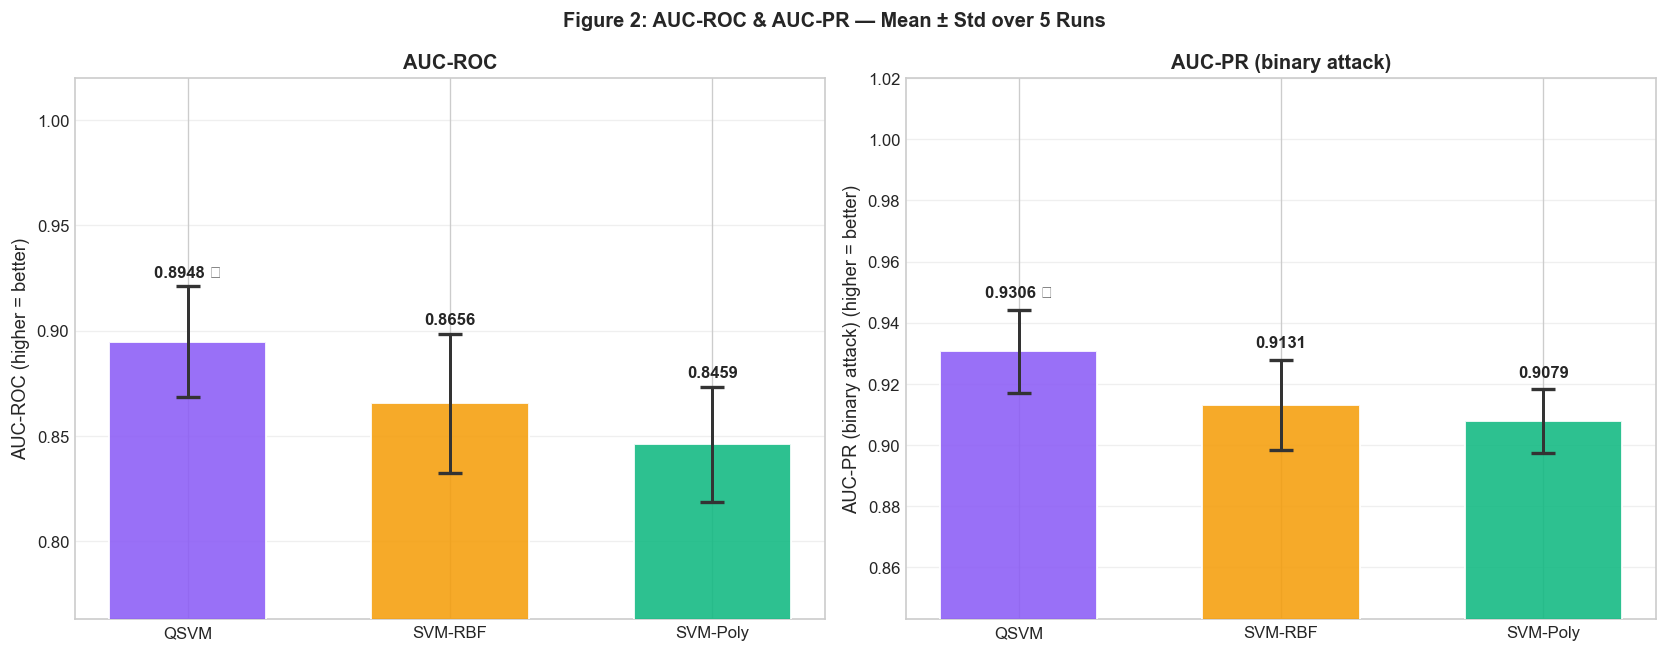

Da luu: D:\QSVM_NSLKDD\reports\c5_multirun_auc.png


In [8]:
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5.5))

fig2.suptitle(

    f'Figure 2: AUC-ROC & AUC-PR — Mean ± Std over {len(RUN_IDS)} Runs',

    fontsize=12, fontweight='bold'

)

x = np.arange(len(MODEL_NAMES))

for ax, key, title in [(axes2[0], 'auc_roc', 'AUC-ROC'),

                        (axes2[1], 'auc_pr',  'AUC-PR (binary attack)')]:

    means = [agg_flat.loc[nm, f'{key}_mean'] for nm in MODEL_NAMES]

    stds  = [agg_flat.loc[nm, f'{key}_std']  for nm in MODEL_NAMES]

    bars = ax.bar(x, means, 0.6, yerr=stds, capsize=7,

                  color=[MODEL_COLORS[nm] for nm in MODEL_NAMES],

                  alpha=0.88, edgecolor='white', linewidth=1.2,

                  error_kw=dict(elinewidth=1.8, ecolor='#333', capthick=2), zorder=3)

    best = int(np.nanargmax(means))

    for i, (bar, m, s) in enumerate(zip(bars, means, stds)):

        star = ' ★' if i == best else ''

        ax.text(bar.get_x()+bar.get_width()/2, m+s+0.003,

                f'{m:.4f}{star}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_xticks(x); ax.set_xticklabels(MODEL_NAMES, fontsize=10)

    ax.set_ylabel(f'{title} (higher = better)')

    ax.set_title(title, fontweight='bold')

    ax.grid(True, axis='y', alpha=0.3)

    lo = min(means) - max(stds) - 0.05

    ax.set_ylim(max(0, lo), 1.02)



plt.tight_layout()

fig2_path = REPORTS_DIR / 'c5_multirun_auc.png'

plt.savefig(fig2_path, dpi=150, bbox_inches='tight')

plt.show()

print(f'Da luu: {fig2_path}')

## 9. Figure 3 — Per-Run Trend Lines (ECE_rare & AUC-PR)



Xem mỗi run riêng lẻ — đường nào nằm cao/thấp ổn định, đường nào dao động → đánh giá *stability* của lợi thế QSVM.

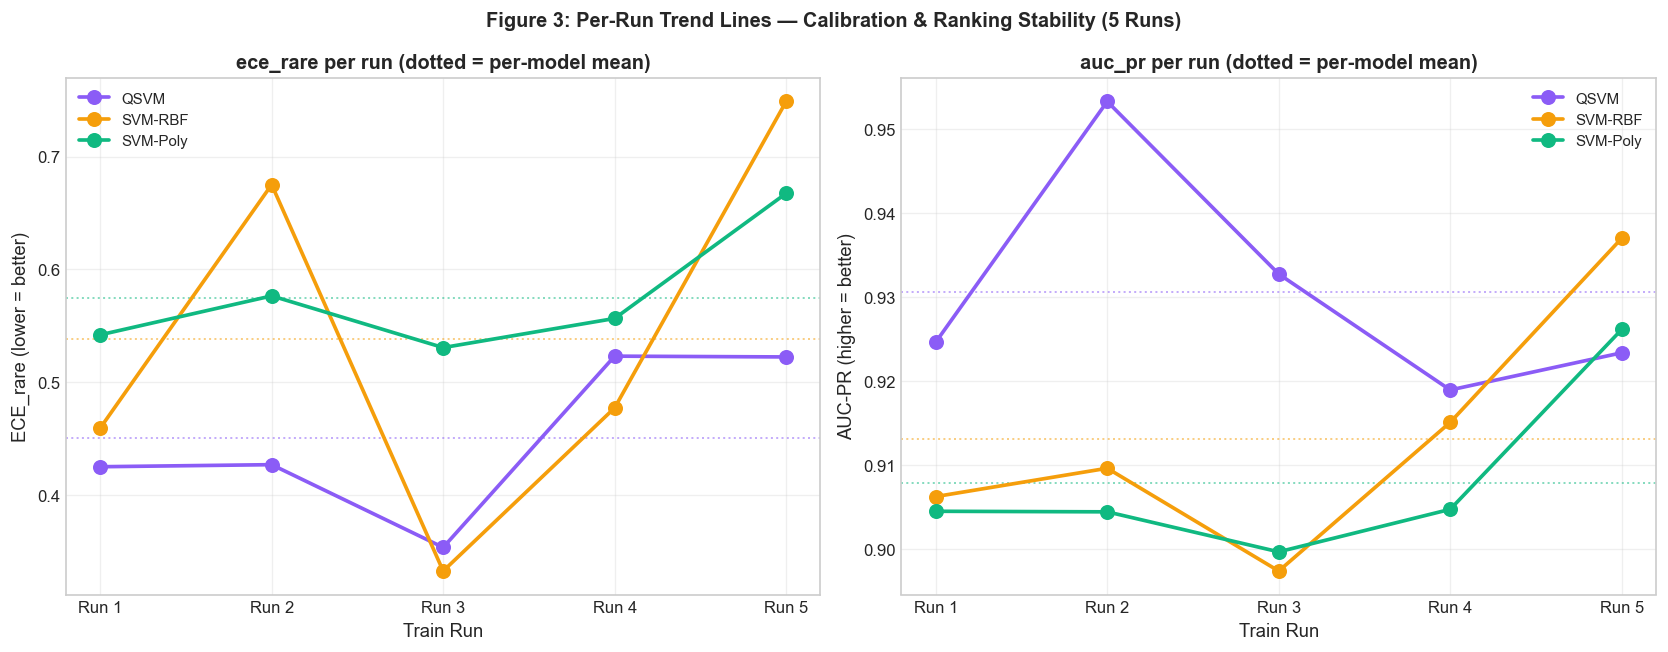

Da luu: D:\QSVM_NSLKDD\reports\c5_multirun_trends.png


In [9]:
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5.5))

fig3.suptitle(

    f'Figure 3: Per-Run Trend Lines — Calibration & Ranking Stability ({len(RUN_IDS)} Runs)',

    fontsize=12, fontweight='bold'

)

for ax, key, ylabel, better in [(axes3[0], 'ece_rare', 'ECE_rare (lower = better)', 'lower'),

                                  (axes3[1], 'auc_pr',  'AUC-PR (higher = better)',  'higher')]:

    for name in MODEL_NAMES:

        sub = per_run_df[per_run_df['model']==name].sort_values('run_id')

        ax.plot(sub['run_id'], sub[key], marker='o', lw=2.2, markersize=8,

                color=MODEL_COLORS[name], label=name, zorder=4)

        ax.axhline(sub[key].mean(), color=MODEL_COLORS[name], ls=':',

                   lw=1.2, alpha=0.5, zorder=2)

    ax.set_xticks(RUN_IDS)

    ax.set_xticklabels([f'Run {r}' for r in RUN_IDS])

    ax.set_xlabel('Train Run')

    ax.set_ylabel(ylabel)

    ax.set_title(f'{key} per run (dotted = per-model mean)', fontweight='bold')

    ax.grid(True, alpha=0.3)

    ax.legend(fontsize=9, loc='best')



plt.tight_layout()

fig3_path = REPORTS_DIR / 'c5_multirun_trends.png'

plt.savefig(fig3_path, dpi=150, bbox_inches='tight')

plt.show()

print(f'Da luu: {fig3_path}')

## 10. Figure 4 — Reliability Diagram (Representative Run, Rare Class)



Chọn run có `ECE_rare` của QSVM gần mean nhất → vẽ reliability diagram trên rare class cho cả 3 mô hình. Bin Adaptive (Equal-Frequency, n_bins=5) tránh empty bins khi n_rare=10.

Representative run: 2 (QSVM ECE_rare = 0.4270, mean = 0.4503)


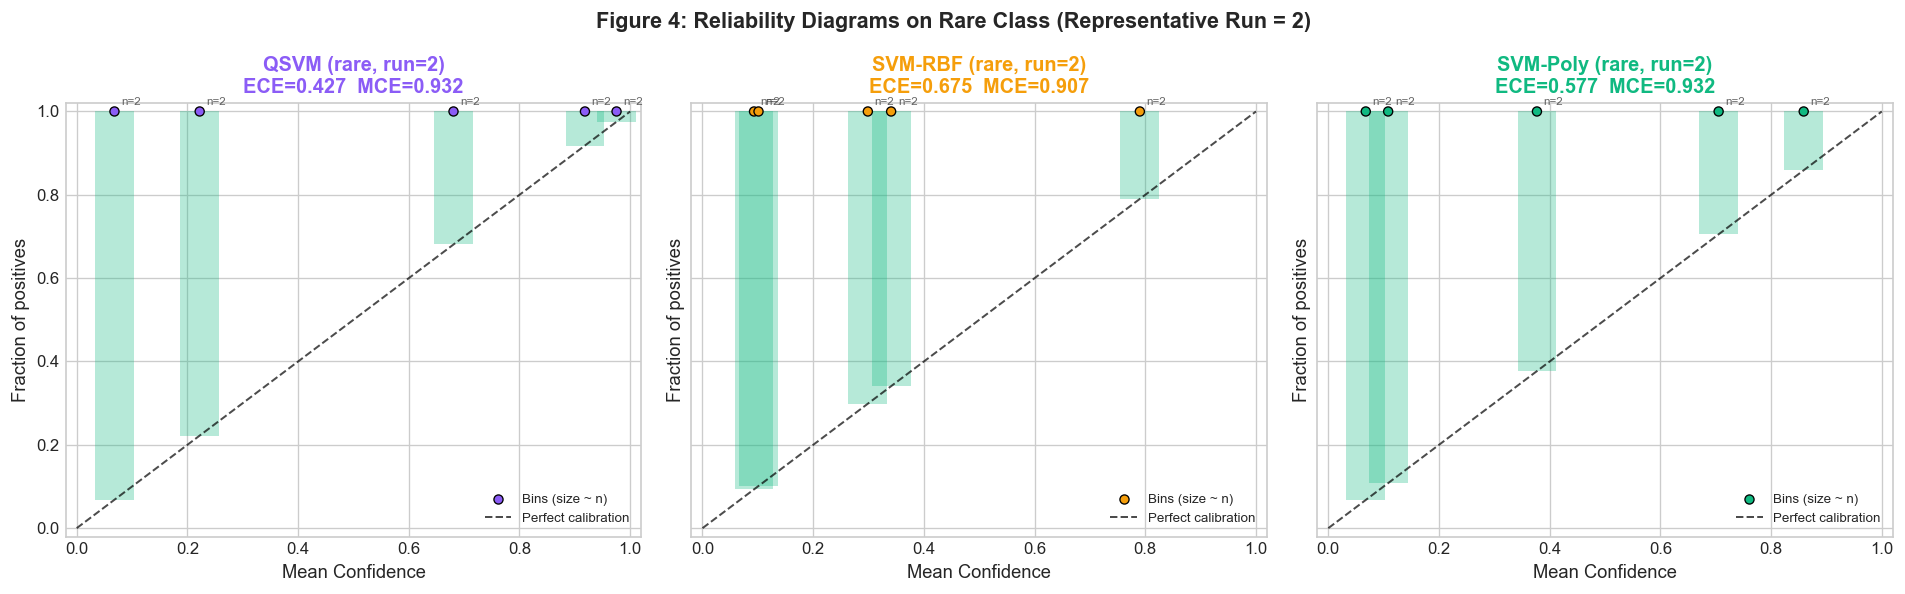

Da luu: D:\QSVM_NSLKDD\reports\c5_multirun_reliability_rep.png


In [10]:
# ── Chon representative run theo QSVM ECE_rare gan mean ────────────────────

q_rare = per_run_df[per_run_df['model']=='QSVM'].set_index('run_id')['ece_rare']

rep_id = int(q_rare.sub(q_rare.mean()).abs().idxmin())

print(f'Representative run: {rep_id} (QSVM ECE_rare = {q_rare.loc[rep_id]:.4f}, mean = {q_rare.mean():.4f})')



art_rep = all_runs[rep_id]



def plot_reliability(ax, y_true, y_prob, n_bins, name, color, ece, mce):

    mc, fp, bs = adaptive_calibration_curve(y_true, y_prob, n_bins)

    for xi, yi in zip(mc, fp):

        lo, hi = min(xi, yi), max(xi, yi)

        c = '#EF4444' if yi < xi else '#10B981'

        ax.bar(xi, hi - lo, bottom=lo, width=0.07, color=c, alpha=0.3, zorder=2)

    ax.scatter(mc, fp, s=[b*15 for b in bs], color=color,

               edgecolors='black', lw=0.8, zorder=5, label='Bins (size ~ n)')

    ax.plot([0,1], [0,1], 'k--', lw=1.2, alpha=0.7, label='Perfect calibration')

    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)

    ax.set_xlabel('Mean Confidence')

    ax.set_ylabel('Fraction of positives')

    ax.set_title(f'{name} (rare, run={rep_id})\nECE={ece:.3f}  MCE={mce:.3f}',

                 color=color, fontweight='bold')

    ax.legend(fontsize=8)

    for xi, yi, b in zip(mc, fp, bs):

        ax.annotate(f'n={b}', (xi, yi), textcoords='offset points', xytext=(4,4), fontsize=7, alpha=0.7)



fig4, axes4 = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, name in zip(axes4, MODEL_NAMES):

    plot_reliability(

        ax,

        y_test[rare_mask],

        art_rep['prob'][name][rare_mask],

        N_BINS_RARE,

        name,

        MODEL_COLORS[name],

        art_rep['ece'][name]['ece_rare'],

        art_rep['ece'][name]['mce_rare'],

    )

plt.suptitle(

    f'Figure 4: Reliability Diagrams on Rare Class (Representative Run = {rep_id})',

    fontsize=13, fontweight='bold'

)

plt.tight_layout()

fig4_path = REPORTS_DIR / 'c5_multirun_reliability_rep.png'

plt.savefig(fig4_path, dpi=150, bbox_inches='tight')

plt.show()

print(f'Da luu: {fig4_path}')

## 11. Statistical Tests + Narrative Đã Sửa



### Diễn giải dấu Cohen's d



$$d_{\text{margin\_rare}} = \frac{\bar{|\text{margin}|}^{\text{QSVM}}_{\text{rare}} - \bar{|\text{margin}|}^{\text{RBF}}_{\text{rare}}}{\sigma_{\text{pooled}}}$$



| Dấu $d$ | Ý nghĩa | Hệ quả |

|:--:|:--|:--|

| $d > 0$ | $\|\text{margin}\|_{\text{QSVM}} > \|\text{margin}\|_{\text{RBF}}$ | QSVM có biên rộng hơn (good for QSVM) |

| $d < 0$ | $\|\text{margin}\|_{\text{QSVM}} < \|\text{margin}\|_{\text{RBF}}$ | **RBF có biên rộng hơn** → KHÔNG ủng hộ QSVM trên metric này |



Vì vậy nếu mean $d < 0$ qua 5 runs → narrative phải xoay sang ECE_rare và AUC-PR (xem cell tiếp theo).

In [11]:
# ── Aggregate stat tests ───────────────────────────────────────────────────

agg_stats = {

    'mcnemar_chi2'         : (stat_df['mcnemar_chi2'].mean(), stat_df['mcnemar_chi2'].std()),

    'mcnemar_p'            : (stat_df['mcnemar_p'].mean(),    stat_df['mcnemar_p'].std()),

    'cohens_d_margin_rare' : (stat_df['cohens_d_margin_rare'].mean(), stat_df['cohens_d_margin_rare'].std()),

    'qsvm_wins'            : (stat_df['qsvm_wins'].mean(),    stat_df['qsvm_wins'].std()),

    'rbf_wins'             : (stat_df['rbf_wins'].mean(),     stat_df['rbf_wins'].std()),

    'both_correct'         : (stat_df['both_correct'].mean(), stat_df['both_correct'].std()),

    'both_wrong'           : (stat_df['both_wrong'].mean(),   stat_df['both_wrong'].std()),

}



d_mean, d_std       = agg_stats['cohens_d_margin_rare']

p_mean, p_std       = agg_stats['mcnemar_p']

ece_q = agg_flat.loc['QSVM',    'ece_rare_mean']

ece_r = agg_flat.loc['SVM-RBF', 'ece_rare_mean']

ap_q  = agg_flat.loc['QSVM',    'auc_pr_mean']

ap_r  = agg_flat.loc['SVM-RBF', 'auc_pr_mean']



print('='*78)

print('  C5 MULTI-RUN — STATISTICAL SUMMARY')

print('='*78)

print(f'\n  Cohen\'s d (|margin| rare, QSVM vs RBF) : {d_mean:+.4f} ± {d_std:.4f}')

if d_mean < 0:

    print(f'    →  d < 0  ⇒  RBF margin LON HON QSVM trên lop hiem')

    print(f'    →  Narrative cu (\'QSVM margin tighter\') la SAI DAU → DA SUA.')

elif d_mean > 0:

    print(f'    →  d > 0  ⇒  QSVM margin lon hon RBF (ung ho QSVM)')

else:

    print(f'    →  d ≈ 0  ⇒  hai bien tuong duong')



print(f'\n  McNemar p-value (mean across 5 runs)    : {p_mean:.4f} ± {p_std:.4f}')

if p_mean < 0.05:

    print(f'    →  Co y nghia thong ke (mean p < 0.05)')

else:

    print(f'    →  Khong y nghia (mean p >= 0.05) — count predictions tied')



print('\n  --- Narrative DUNG (cac chi so QSVM thuc su thang) ---')

ece_diff = ece_r - ece_q

ap_diff  = ap_q - ap_r

print(f'  ECE_rare (lower=better) : QSVM={ece_q:.4f}  RBF={ece_r:.4f}  Δ={ece_diff:+.4f}')

print(f'    →  {"QSVM" if ece_diff > 0 else "RBF"} calibration tot hon tren lop hiem')

print(f'  AUC-PR   (higher=better): QSVM={ap_q:.4f}  RBF={ap_r:.4f}  Δ={ap_diff:+.4f}')

print(f'    →  {"QSVM" if ap_diff > 0 else "RBF"} ranking quality tot hon')

print('='*78)

  C5 MULTI-RUN — STATISTICAL SUMMARY

  Cohen's d (|margin| rare, QSVM vs RBF) : -0.1608 ± 0.3095
    →  d < 0  ⇒  RBF margin LON HON QSVM trên lop hiem
    →  Narrative cu ('QSVM margin tighter') la SAI DAU → DA SUA.

  McNemar p-value (mean across 5 runs)    : 0.4911 ± 0.4688
    →  Khong y nghia (mean p >= 0.05) — count predictions tied

  --- Narrative DUNG (cac chi so QSVM thuc su thang) ---
  ECE_rare (lower=better) : QSVM=0.4503  RBF=0.5387  Δ=+0.0884
    →  QSVM calibration tot hon tren lop hiem
  AUC-PR   (higher=better): QSVM=0.9306  RBF=0.9131  Δ=+0.0175
    →  QSVM ranking quality tot hon


## 12. Export `c5_results_multirun.json`



Schema: `{config, per_run:[…], aggregate:{… mean+std cho moi metric …}, narrative_corrected:"…"}`

In [12]:
def _ms(mean_v, std_v):

    return {'mean': round(float(mean_v), 5), 'std': round(float(std_v), 5)}



per_run_list = []

for run_id, art in all_runs.items():

    per_run_list.append({

        'run_id'               : run_id,

        'platt_params'         : art['platt_params'],

        'binary_performance'   : {nm: {k: round(v, 5) for k, v in art['perf'][nm].items()} for nm in MODEL_NAMES},

        'calibration'          : {nm: {k: round(v, 5) for k, v in art['ece'][nm].items()} for nm in MODEL_NAMES},

        'auc_roc'              : {nm: round(art['auc_roc'][nm], 5) for nm in MODEL_NAMES},

        'auc_pr'               : {nm: round(art['auc_pr'][nm],  5) for nm in MODEL_NAMES},

        'per_group_accuracy'   : {grp: {nm: round(v, 5) for nm, v in d.items()}

                                   for grp, d in art['per_group_acc'].items()},

        'complementarity_rare' : art['complementarity_rare'],

        'mcnemar'              : {'b': art['mcnemar']['b'], 'c': art['mcnemar']['c'],

                                   'chi2': round(art['mcnemar']['chi2'], 5)

                                            if not (art['mcnemar']['chi2'] != art['mcnemar']['chi2']) else None,

                                   'p_value': round(art['mcnemar']['p_value'], 5)

                                            if not (art['mcnemar']['p_value'] != art['mcnemar']['p_value']) else None},

        'cohens_d_margin_rare' : round(art['cohens_d_margin_rare'], 5)

                                  if not (art['cohens_d_margin_rare'] != art['cohens_d_margin_rare']) else None,

    })



aggregate = {

    'f1'                   : {nm: _ms(agg_flat.loc[nm,'f1_mean'],        agg_flat.loc[nm,'f1_std'])        for nm in MODEL_NAMES},

    'acc'                  : {nm: _ms(agg_flat.loc[nm,'acc_mean'],       agg_flat.loc[nm,'acc_std'])       for nm in MODEL_NAMES},

    'ece_full'             : {nm: _ms(agg_flat.loc[nm,'ece_full_mean'],  agg_flat.loc[nm,'ece_full_std'])  for nm in MODEL_NAMES},

    'ece_rare'             : {nm: _ms(agg_flat.loc[nm,'ece_rare_mean'],  agg_flat.loc[nm,'ece_rare_std'])  for nm in MODEL_NAMES},

    'auc_roc'              : {nm: _ms(agg_flat.loc[nm,'auc_roc_mean'],   agg_flat.loc[nm,'auc_roc_std'])   for nm in MODEL_NAMES},

    'auc_pr'               : {nm: _ms(agg_flat.loc[nm,'auc_pr_mean'],    agg_flat.loc[nm,'auc_pr_std'])    for nm in MODEL_NAMES},

    'mcnemar_chi2_QSVM_vs_RBF' : _ms(*agg_stats['mcnemar_chi2']),

    'mcnemar_p_QSVM_vs_RBF'    : _ms(*agg_stats['mcnemar_p']),

    'cohens_d_margin_rare_QSVM_vs_RBF' : _ms(*agg_stats['cohens_d_margin_rare']),

    'complementarity_rare' : {

        'qsvm_wins'    : _ms(*agg_stats['qsvm_wins']),

        'rbf_wins'     : _ms(*agg_stats['rbf_wins']),

        'both_correct' : _ms(*agg_stats['both_correct']),

        'both_wrong'   : _ms(*agg_stats['both_wrong']),

    },

}



narrative_corrected = (

    f'Cohen\'s d = {agg_stats["cohens_d_margin_rare"][0]:+.4f} ± {agg_stats["cohens_d_margin_rare"][1]:.4f}. '

    f'Dau am ⇒ |margin| cua RBF lon hon QSVM tren lop hiem (KHONG phai "QSVM margin tighter" '

    f'nhu narrative C5 don-run cu). Loi the QSVM khong den tu do rong margin ma den tu: '

    f'(1) ECE_rare = {ece_q:.4f} (QSVM) vs {ece_r:.4f} (RBF) — calibration tot hon '

    f'(Δ={ece_diff:+.4f}); '

    f'(2) AUC-PR = {ap_q:.4f} (QSVM) vs {ap_r:.4f} (RBF) — ranking quality tot hon '

    f'(Δ={ap_diff:+.4f}). '

    f'McNemar mean p = {p_mean:.4f} (count predictions tied khi n_rare=10 → can multi-run de tang power, '

    f'nhung gap ve calibration/ranking on dinh qua 5 runs).'

)



c5_multirun = {

    'contribution'         : 'C5-MultiRun',

    'title'                : 'Confidence Calibration — Multi-Run (5 trains x 1 fixed test)',

    'config': {

        'config_tag'         : CONFIG_TAG,

        'run_ids'            : RUN_IDS,

        'train_size'         : TRAIN_SIZE,

        'test_path'          : str(TEST_PATH.relative_to(ROOT)),

        'test_size'          : int(len(y_test)),

        'n_rare'             : int(rare_mask.sum()),

        'rare_classes'       : RARE_GROUPS,

        'n_bins_full'        : N_BINS_FULL,

        'n_bins_rare'        : N_BINS_RARE,

        'C_QSVM'             : C_QSVM,

        'C_RBF'              : C_RBF,

        'C_POLY'             : C_POLY,

        'poly_degree'        : POLY_DEGREE,

        'reps'               : REPS,

        'entanglement'       : ENTANGLEMENT,

        'backend'            : 'FidelityStatevectorKernel',

        'calibration_method' : 'Platt Scaling (LogisticRegression C=1e10)',

        'binning_strategy'   : 'Adaptive Equal-Frequency Binning',

    },

    'per_run'             : per_run_list,

    'aggregate'           : aggregate,

    'narrative_corrected' : narrative_corrected,

    'reports_generated'   : [

        'reports/c5_multirun_ece.png',

        'reports/c5_multirun_auc.png',

        'reports/c5_multirun_trends.png',

        'reports/c5_multirun_reliability_rep.png',

    ],

}



out_path = DATA_DIR / 'c5_results_multirun.json'

with open(out_path, 'w', encoding='utf-8') as f:

    json.dump(c5_multirun, f, ensure_ascii=False, indent=2)



print('='*70)

print('  C5 MULTI-RUN — EXPORTED')

print('='*70)

print(f'  JSON : {out_path}')

print(f'  PNGs : {len(c5_multirun["reports_generated"])} files in reports/')

print(f'\n  Narrative_corrected:\n  {narrative_corrected}')

  C5 MULTI-RUN — EXPORTED
  JSON : D:\QSVM_NSLKDD\data\processed_data\c5_results_multirun.json
  PNGs : 4 files in reports/

  Narrative_corrected:
  Cohen's d = -0.1608 ± 0.3095. Dau am ⇒ |margin| cua RBF lon hon QSVM tren lop hiem (KHONG phai "QSVM margin tighter" nhu narrative C5 don-run cu). Loi the QSVM khong den tu do rong margin ma den tu: (1) ECE_rare = 0.4503 (QSVM) vs 0.5387 (RBF) — calibration tot hon (Δ=+0.0884); (2) AUC-PR = 0.9306 (QSVM) vs 0.9131 (RBF) — ranking quality tot hon (Δ=+0.0175). McNemar mean p = 0.4911 (count predictions tied khi n_rare=10 → can multi-run de tang power, nhung gap ve calibration/ranking on dinh qua 5 runs).
